This notebook runs **normative modeling** of **functional connectivity** data **per network** as a function of **age**. This enables the build of **normative charts of functional connectivity in healthy aging**, embracing both diversity and uncertainty from a cohort of 1000 healthy subjects. A battery of models (statistical frameorks) are fitted to the empirical data through Hierarchical Bayesian Regression proposed in the package Predictive Clinical Neuroscience toolkit (pcntoolkit, https://pcntoolkit.readthedocs.io/en/latest/). The trade-off between predictive power and complexity of the models is assessed through bayesian model comparison, guiding for the choice of an adequate normative model describing this empirical data of functional connectivity. 

In [1]:
import warnings
#removing annoying warnings related to pymc dependencies in pcntoolkit 
warnings.filterwarnings("ignore", category=FutureWarning)

import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize':14, 'axes.titlesize':16})
import pickle
import pcntoolkit as ptk  
import arviz as az
from itertools import product


from funcs import *

## Loading the data

Here a .json containing demographic data of subjects and their FC matrices computed from BOLD FMRI recordings.

In [2]:
cwd = os.getcwd()

In [3]:
fc_df = pd.read_json('FUNC_df.json')

In [4]:
fc_df.isna().sum()

SubjectID    0
Age          1
FC           0
FCD          0
dtype: int64

In [5]:
fc_df = fc_df.dropna()
fc_df['FC'] = fc_df['FC'].apply(np.array)

We break down the functional connectivity into the 7 networks 

In [6]:
with open('../Structural/Schaefer2018_100Parcels_7Networks_order_info.txt', 'r') as f:
    lines = f.read().splitlines()

In [7]:
net_labels = lines[::2]
roi_index = [int(l[:l.find(' ')]) for l in lines[1::2]]
roi_index = np.array(roi_index) - 1

In [8]:
net_df = pd.DataFrame({'label': net_labels, 'index': roi_index})
net_df['hemis'] = net_df.label.apply(lambda x: x[10:12])
net_df['net'] = net_df.label.apply(lambda x: x[13:][:x[13:].find('_')])
net_indices = net_df.groupby('net')['index'].apply(list)

In [9]:
net_matching = {}
for net in net_indices.index.values :
    net_matching[net] = np.ix_(net_indices[net], net_indices[net])

In [10]:
for net in net_matching.keys() :
    fc_df['FC_' + net] = fc_df['FC'].apply(lambda x: x[net_matching[net]])
    fc_df['Mean_FC_' + net] = fc_df['FC_' + net].apply(np.mean)
    fc_df['Var_FC_' + net] = fc_df['FC_' + net].apply(np.var)

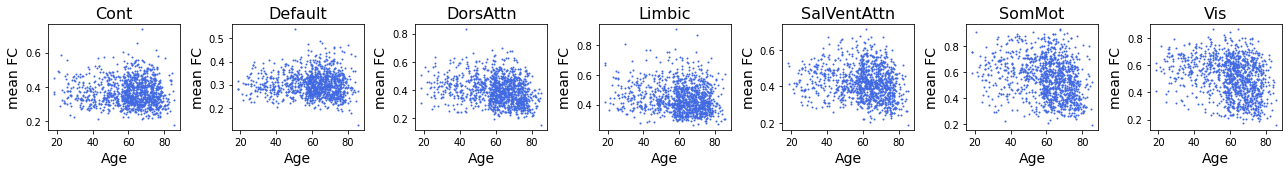

In [11]:
fig, ax = plt.subplots(ncols=7, figsize=(18, 2.5))
for i, net in enumerate(net_matching.keys()) :
    ax[i].scatter(fc_df['Age'], fc_df['Mean_FC_' + net], s=1, color='royalblue')
    ax[i].set(title=net, xlabel='Age', ylabel='mean FC')
fig.tight_layout()

We fit different parameterizations of linear, generalized additive models (GAM) and GAMLSS (GAM of location scale and shape) to each of the network-FC as a function of age and we select the best fit based on model comparison.

In [12]:
nets = list(net_matching.keys())

In [13]:
#Run and save all models 
x_str = 'Age' ;  y = 'Mean_FC_'
for net in nets :
    y_str = y + net
    models_dict = run_all(fc_df, x_str, y_str, reg_type='linear')

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_FC_Cont.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
There were 250 divergences after tuning. Increase `target_accept` or reparameterize.


Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_FC_Cont.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 40 seconds.


Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_FC_Vis.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, slope_sigma, intercept_sigma, slope_epsilon, intercept_epsilon, slope_delta, intercept_delta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.


In [14]:
#Load models and perform model comparison, per each network
x_str = 'Age' ;  y = 'Mean_FC_'
model_names = get_names(reg_type='all')
best_list = []
for net in nets :
    y_str = y + net
    models_dict, compared = compare_from_pickles(fc_df, x_str, y_str, model_names)
    best = get_best(compared)
    best_list.append(best)

Sampling: [sigma, y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

/media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/funcs.py:329: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/funcs.py:329: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1038: RuntimeWarning: overflow encountered in divide
  b_ary /= prior_bs * ary[i

In [15]:
#Load best model per network
nms = []
for b, net in zip(best_list, nets) :
    print(net, 'best :', b)
    y_str = y + net
    nm = nm_from_pickle(x_str, y_str, b)
    nms.append(nm)

Cont best : lin_shash_sig_eps
Default best : gamlss_sig
DorsAttn best : gam_het
Limbic best : lin_shash_sig_eps
SalVentAttn best : gam_het
SomMot best : gam_het
Vis best : gam_het


We plot the best fit for each network-FC

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

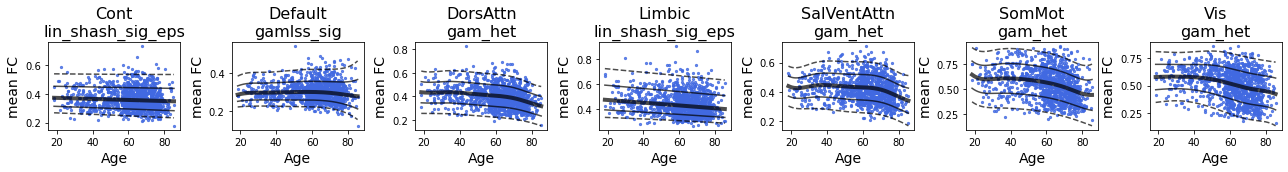

In [16]:
fig, ax = plt.subplots(ncols=7, figsize=(18, 2.5))
for i, net in enumerate(nets) :
    y_str = y + net
    inscaler = ptk.util.utils.scaler('standardize') 
    outscaler = ptk.util.utils.scaler('standardize')
    outscaler.fit_transform(fc_df[y_str])
    a=plot_quantiles(nms[i], fc_df, x_str, y_str, inscaler, outscaler, n_qs=2, ax=ax[i])
    ax[i].set(title=net + '\n' + best_list[i], xlabel='Age', ylabel='mean FC')
    #ax[i].axhline(fc_df[y_str].mean(), linestyle='--', lw=2, color='red', alpha=.8)
fig.tight_layout()